# XGBoost Model Machine learning notebook for Industrial Analytics
Build by: John Olukayode<br>
Goal: Build a machine learning model using XGBoost and visualize it's performance

## Why this project matters

Forecasting demand helps avoid stockouts/overstock, plan staffing, and time promotions using real sales + store + product + inventory data.

### Pipeline steps (what we did)

1) Data preparation (clean types, handle missing)
2) Train/validation split
3) Encode categoricals (get_dummies)
4) Scale numeric features (StandardScaler)
5) Train XGBRegressor
6) Evaluate (RMSE/MAE/R²)
7) Interpret (feature importance)






## 1 Data Preparation and further Data Exploration

### 1.1 Data Prept Delete rows from train data for closed stores

In [ ]:
base_path = '../data/'
calendar_df = pd.read_csv(base_path + 'calendar.csv')
inventory_df = pd.read_csv(base_path + 'inventory.csv')
products_df = pd.read_csv(base_path + 'products.csv')
sales_df = pd.read_csv(base_path + 'sales.csv')
stores_df = pd.read_csv(base_path + 'stores.csv')

# Standardize column names (safety)
sales_df.columns   = [c.strip() for c in sales_df.columns]
stores_df.columns  = [c.strip() for c in stores_df.columns]
products_df.columns= [c.strip() for c in products_df.columns]
inventory_df.columns=[c.strip() for c in inventory_df.columns]
calendar_df.columns=[c.strip() for c in calendar_df.columns]

# Parse dates
sales_df["Date"] = pd.to_datetime(sales_df["Date"], errors="coerce")
stores_df["Store_Open_Date"] = pd.to_datetime(stores_df["Store_Open_Date"], errors="coerce")
calendar_df["Date"] = pd.to_datetime(calendar_df["Date"], errors="coerce")

# Coerce numeric IDs / Units
for col in ["Sale_ID","Store_ID","Product_ID","Units"]:
    if col in sales_df.columns:
        sales_df[col] = pd.to_numeric(sales_df[col], errors="coerce")

print("Sales shape BEFORE cleaning:", sales_df.shape)

# Attach store open date so we can filter invalid rows
sales_with_open = sales_df.merge(
    stores_df[["Store_ID", "Store_Open_Date"]],
    on="Store_ID",
    how="left",
    validate="many_to_one"
)

# Flag invalid rows: before open date OR missing store open date OR missing sales date
invalid_date_rows = (
    sales_with_open["Date"].isna() |
    sales_with_open["Store_Open_Date"].isna() |
    (sales_with_open["Date"] < sales_with_open["Store_Open_Date"])
)

# Basic quality filters
valid_units = sales_with_open["Units"].fillna(0) > 0

sales_clean = sales_with_open.loc[~invalid_date_rows & valid_units].copy()

Sales shape BEFORE cleaning: (829262, 5)


In [ ]:

import pandas as pd
import numpy as np


def standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    return df

def money_to_float(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
              .str.replace("$", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.strip()
    )

sales_clean = standardize_cols(sales_clean)
stores_std  = standardize_cols(stores_df)
products_std = standardize_cols(products_df)
inventory_std = standardize_cols(inventory_df)
calendar_std = standardize_cols(calendar_df)

# sales date
if "Date" in sales_clean.columns:
    sales_clean["Date"] = pd.to_datetime(sales_clean["Date"], errors="coerce")

if "Store_Open_Date" in stores_std.columns:
    stores_std["Store_Open_Date"] = pd.to_datetime(stores_std["Store_Open_Date"], errors="coerce")

if "Date" in calendar_std.columns:
    calendar_std["Date"] = pd.to_datetime(calendar_std["Date"], errors="coerce", infer_datetime_format=True)

products_clean = products_std.copy()
for col in ["Product_Cost", "Product_Price"]:
    if col in products_clean.columns:
        products_clean[col] = pd.to_numeric(money_to_float(products_clean[col]), errors="coerce")

inventory_clean = inventory_std.copy()
for col in ["Store_ID", "Product_ID", "Stock_On_Hand"]:
    if col in inventory_clean.columns:
        inventory_clean[col] = pd.to_numeric(inventory_clean[col], errors="coerce")

fact_sales = (
    sales_clean
      .merge(stores_std, on="Store_ID", how="left", validate="many_to_one", suffixes=("", "_store"))
      .merge(products_clean, on="Product_ID", how="left", validate="many_to_one", suffixes=("", "_prod"))
      .merge(inventory_clean, on=["Store_ID","Product_ID"], how="left", validate="many_to_one", suffixes=("", "_inv"))
      .merge(calendar_std, on="Date", how="left", validate="many_to_one", suffixes=("", "_cal"))
)

store_open_candidates = [c for c in fact_sales.columns if c.lower().replace(" ", "") in {
    "store_open_date", "store_open_date_store"
}]
if len(store_open_candidates) == 0:
    print("Available columns that contain 'Open' or 'Date':")
    print([c for c in fact_sales.columns if ("Open" in c) or ("Date" in c)])
    raise KeyError("Store_Open_Date not found in fact_sales after merges. Check store column naming.")
else:
    store_open_col = store_open_candidates[0]

if "Units" in fact_sales.columns and "Product_Price" in fact_sales.columns:
    fact_sales["Revenue"] = fact_sales["Units"] * fact_sales["Product_Price"]

fact_sales["Date"] = pd.to_datetime(fact_sales["Date"], errors="coerce")
fact_sales[store_open_col] = pd.to_datetime(fact_sales[store_open_col], errors="coerce")

fact_sales["StoreAgeDays"] = (fact_sales["Date"] - fact_sales[store_open_col]).dt.days

print("Unified fact table shape:", fact_sales.shape)
display(fact_sales.head())
print("\nStore open date column used:", store_open_col)


C:\Users\kings\AppData\Local\Temp\ipykernel_21316\184222666.py:32: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  calendar_std["Date"] = pd.to_datetime(calendar_std["Date"], errors="coerce", infer_datetime_format=True)


Unified fact table shape: (829262, 17)


,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Open_Date,Store_Name,Store_City,Store_Location,Store_Open_Date_store,Product_Name,Product_Category,Product_Cost,Product_Price,Stock_On_Hand,Revenue,StoreAgeDays
0,1,2022-01-01,24,4,1,2010-07-31,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,1.0,12.99,4172
1,2,2022-01-01,28,1,1,2011-04-01,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,6.0,15.99,3928
2,3,2022-01-01,6,8,1,2003-12-13,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99,50.0,6.99,6594
3,4,2022-01-01,48,7,1,2016-03-23,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,11.99,15.99,28.0,15.99,2110
4,5,2022-01-01,44,18,1,2014-12-27,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,34.99,39.99,117.0,39.99,2562



Store open date column used: Store_Open_Date


In [ ]:
df_model = (
    fact_sales
    .groupby(["Date", "Store_ID", "Product_ID"], as_index=False)
    .agg({
        "Units": "sum",
        "Revenue": "sum",
        "Stock_On_Hand": "mean",
        "Product_Price": "mean",
        "Product_Cost": "mean",
        "StoreAgeDays": "mean",
        "Store_City": "first",
        "Store_Location": "first",
        "Product_Category": "first",
        "Store_Name": "first",
        "Product_Name": "first",
    })
)

df_model["Year"] = df_model["Date"].dt.year
df_model["Month"] = df_model["Date"].dt.month
df_model["Day"] = df_model["Date"].dt.day
df_model["DayOfWeek"] = df_model["Date"].dt.dayofweek
df_model["WeekOfYear"] = df_model["Date"].dt.isocalendar().week.astype(int)

print("Model dataset shape:", df_model.shape)
display(df_model.head())

Model dataset shape: (88291, 19)


,Date,Store_ID,Product_ID,Units,Revenue,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Store_City,Store_Location,Product_Category,Store_Name,Product_Name,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,1,21,35,349.65,21.0,9.99,6.99,10697.0,Guadalajara,Residential,Sports & Outdoors,Maven Toys Guadalajara 1,Mini Ping Pong Set,2022,1,1,5,52
1,2022-01-01,1,31,9,80.91,7.0,8.99,7.99,10697.0,Guadalajara,Residential,Sports & Outdoors,Maven Toys Guadalajara 1,Splash Balls,2022,1,1,5,52
2,2022-01-01,1,34,4,103.96,0.0,25.99,20.99,10697.0,Guadalajara,Residential,Electronics,Maven Toys Guadalajara 1,Toy Robot,2022,1,1,5,52
3,2022-01-01,2,18,5,199.95,38.0,39.99,34.99,9746.0,Monterrey,Residential,Toys,Maven Toys Monterrey 1,Lego Bricks,2022,1,1,5,52
4,2022-01-01,3,8,6,41.94,44.0,6.99,3.99,8041.0,Guadalajara,Commercial,Games,Maven Toys Guadalajara 2,Deck Of Cards,2022,1,1,5,52


## 2 Train/Validation

In [ ]:
target_col = "Units"
feature_cols = [
    "Store_ID","Product_ID",
    "Stock_On_Hand","Product_Price","Product_Cost",
    "StoreAgeDays",
    "Year","Month","Day","DayOfWeek","WeekOfYear",
    "Store_City","Store_Location","Product_Category"
]

feature_cols = [c for c in feature_cols if c in df_model.columns]

X_raw = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print("Selected features:", feature_cols)
print("X_raw shape:", X_raw.shape, "| y shape:", y.shape)
display(X_raw.head())


Selected features: ['Store_ID', 'Product_ID', 'Stock_On_Hand', 'Product_Price', 'Product_Cost', 'StoreAgeDays', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Store_City', 'Store_Location', 'Product_Category']
X_raw shape: (88291, 14) | y shape: (88291,)


,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,WeekOfYear,Store_City,Store_Location,Product_Category
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Electronics
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,52,Monterrey,Residential,Toys
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,52,Guadalajara,Commercial,Games


#### 2.1 Clean Data

In [ ]:


df_clean = pd.concat([X_raw, y.rename("Units")], axis=1)

num_cols = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

num_cols = [c for c in num_cols if c != "Units"]

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Unknown")

q_low, q_high = df_clean["Units"].quantile([0.01, 0.99])
df_clean["Units"] = df_clean["Units"].clip(lower=q_low, upper=q_high)

print("Missing values AFTER cleaning (top):")
display(df_clean.isna().sum().sort_values(ascending=False).head(10))
display(df_clean.head())


Missing values AFTER cleaning (top):


Store_ID         0
Product_ID       0
Stock_On_Hand    0
Product_Price    0
Product_Cost     0
StoreAgeDays     0
Year             0
Month            0
Day              0
DayOfWeek        0
dtype: int64

,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,WeekOfYear,Store_City,Store_Location,Product_Category,Units
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors,35
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors,9
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Electronics,4
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,52,Monterrey,Residential,Toys,5
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,52,Guadalajara,Commercial,Games,6


##### 2.2 Construct Data

In [ ]:
df_feat = df_clean.copy()

df_feat = df_feat.sort_values(["Store_ID","Product_ID","Year","Month","Day"])

df_feat["Date"] = df_model["Date"].values
df_feat = df_feat.sort_values(["Store_ID","Product_ID","Date"])

df_feat["Units_7D_MA_LAG1"] = (
    df_feat.groupby(["Store_ID","Product_ID"])["Units"]
    .shift(1)
    .rolling(window=7, min_periods=1)
    .mean()
)

df_feat["Units_7D_MA_LAG1"] = df_feat["Units_7D_MA_LAG1"].fillna(df_feat["Units_7D_MA_LAG1"].median())

print("Feature set shape after construction:", df_feat.shape)
display(df_feat[["Store_ID","Product_ID","Date","Units","Units_7D_MA_LAG1"]].head(10))

Feature set shape after construction: (88291, 17)


,Store_ID,Product_ID,Date,Units,Units_7D_MA_LAG1
118,1,1,2022-01-01,9,11.285714
294,1,1,2022-01-01,6,9.000000
755,1,1,2022-01-01,3,7.500000
1427,1,1,2022-01-01,3,6.000000
1635,1,1,2022-01-01,3,5.250000
1976,1,1,2022-01-01,14,4.800000
2693,1,1,2022-01-01,9,6.333333
2829,1,1,2022-01-01,16,6.714286
4341,1,1,2022-01-01,14,7.714286
4595,1,1,2022-01-01,6,8.857143


## 3 Encode Categoricals

In [ ]:

from sklearn.model_selection import train_test_split

y_final = df_feat["Units"].copy()

X = df_feat.drop(columns=["Units", "Date"])

X_encoded = pd.get_dummies(X, drop_first=True)

df_feat_sorted = df_feat.sort_values("Date").reset_index(drop=True)
cutoff_idx = int(len(df_feat_sorted) * 0.8)

train_idx = df_feat_sorted.index[:cutoff_idx]
val_idx   = df_feat_sorted.index[cutoff_idx:]

X_encoded_sorted = X_encoded.loc[df_feat_sorted.index]
y_sorted = y_final.loc[df_feat_sorted.index]

X_train = X_encoded_sorted.loc[train_idx]
y_train = y_sorted.loc[train_idx]
X_val   = X_encoded_sorted.loc[val_idx]
y_val   = y_sorted.loc[val_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)

display(X_train.head())


# Save train and validation sets to CSV
train_df = pd.concat([X_train, y_train.rename("Units")], axis=1)
val_df = pd.concat([X_val, y_val.rename("Units")], axis=1)
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("validation_data.csv", index=False)

print("Train and validation datasets saved successfully.")


X_train: (70632, 47) y_train: (70632,)
X_val  : (17659, 47) y_val  : (17659,)


,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,...,Store_City_Villahermosa,Store_City_Xalapa,Store_City_Zacatecas,Store_Location_Commercial,Store_Location_Downtown,Store_Location_Residential,Product_Category_Electronics,Product_Category_Games,Product_Category_Sports & Outdoors,Product_Category_Toys
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,True,False
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,True,False
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,True,False,False,False
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,False,True
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,...,False,False,False,True,False,False,False,True,False,False


Train and validation datasets saved successfully.


## 4 Train XGBRegressor

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

baseline_pred = np.full(shape=len(y_val), fill_value=float(np.mean(y_train)))


try:
    from xgboost import XGBRegressor
except Exception as e:
    raise RuntimeError(
        "XGBoost is not available. Install it with: pip install xgboost"
    ) from e

xgb_model = XGBRegressor(
    n_estimators=600,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)
y_val_pred = xgb_model.predict(X_val)

Baseline RMSE: 9.517346533399781
Baseline MAE : 6.73808770279021
Baseline MAPE: 114.5004063420105


#### Evaluate (RMSE/MAE/R^2)

In [ ]:
print("\nXGBoost RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("XGBoost MAE :", mean_absolute_error(y_val, y_val_pred))
print("XGBoost MAPE:", mape(y_val, y_val_pred))
print("XGBoost R2  :", r2_score(y_val, y_val_pred))



XGBoost RMSE: 9.917184084261661
XGBoost MAE : 7.291881084442139
XGBoost MAPE: 124.97515208410006
XGBoost R2  : -0.08697950839996338


## 5 Access model / Interpret (feature importance)

Validation RMSE: 9.92
Validation MAE : 7.29
Validation R2  : -0.0870


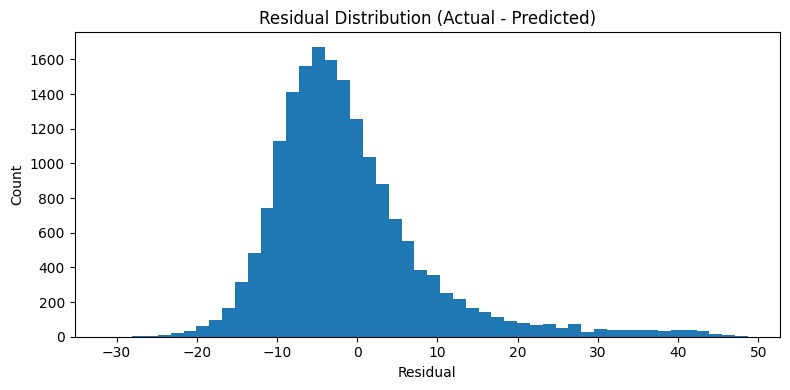

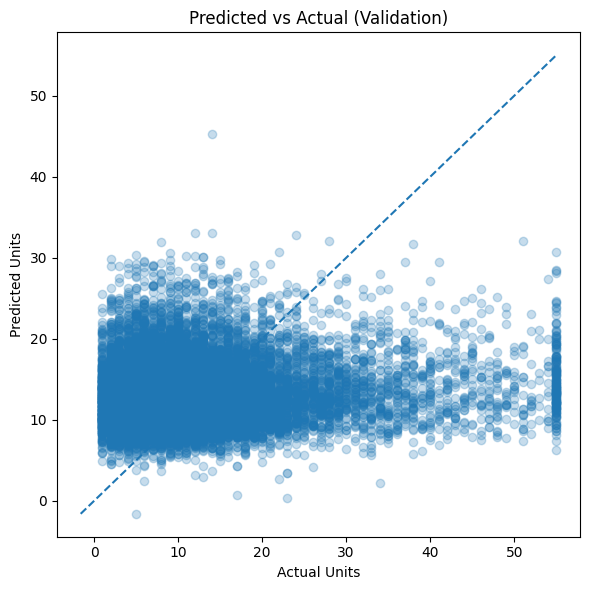

Top 15 important features:


,feature,importance
18,Store_City_Cuidad de Mexico,0.026100
14,Store_City_Chihuahua,0.025751
36,Store_City_Tuxtla Gutierrez,0.025359
12,Store_City_Campeche,0.024910
35,Store_City_Toluca,0.024800
22,Store_City_Guanajuato,0.024431
29,Store_City_Oaxaca,0.023315
27,Store_City_Monterrey,0.023018
42,Store_Location_Residential,0.022945
23,Store_City_Hermosillo,0.022922


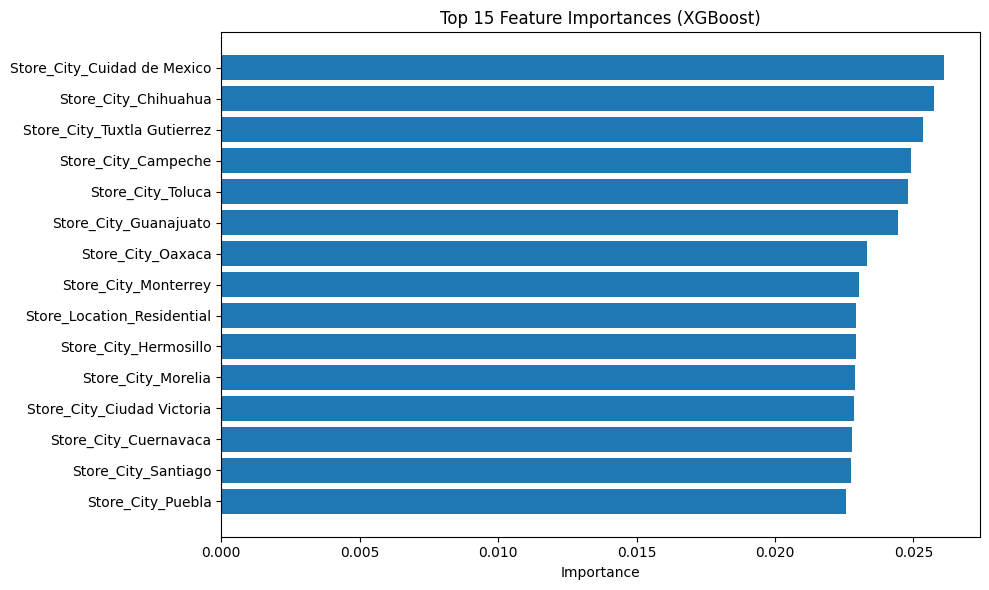

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

assess_model = XGBRegressor(
    n_estimators=600,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

assess_model.fit(X_train, y_train)
pred = assess_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation MAE : {mae:.2f}")
print(f"Validation R2  : {r2:.4f}")

residuals = y_val.values - pred
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Predicted vs Actual
plt.figure(figsize=(6, 6))
plt.scatter(y_val, pred, alpha=0.25)
min_v = float(min(np.min(y_val), np.min(pred)))
max_v = float(max(np.max(y_val), np.max(pred)))
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Predicted vs Actual (Validation)")
plt.xlabel("Actual Units")
plt.ylabel("Predicted Units")
plt.tight_layout()
plt.show()

importances = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": assess_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)

print("Top 15 important features:")
display(importances.head(15))

plt.figure(figsize=(10, 6))
top15 = importances.head(15).iloc[::-1] 
plt.barh(top15["feature"], top15["importance"])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
